# Clase de Procesamiento de Datos - Regresión y Outliers

Este notebook acompaña la clase sobre tratamiento de outliers y uso de modelos de regresión robusta.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor
from sklearn.metrics import mean_squared_error
np.random.seed(42)


## Generación de datos con outliers

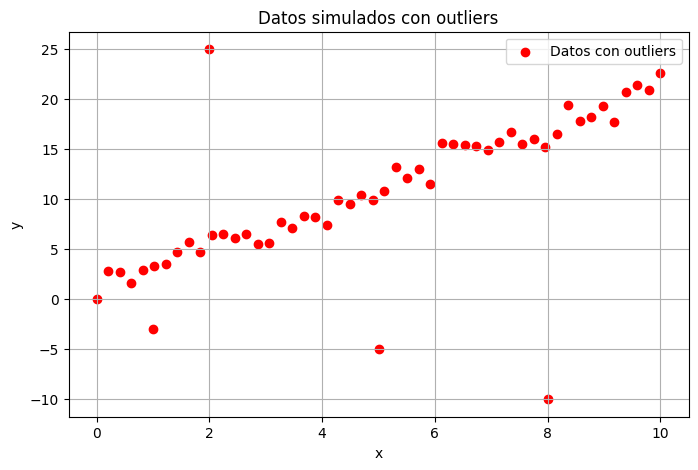

In [14]:
# Datos base: línea recta con ruido
x = np.linspace(0, 10, 50)
y = 2 * x + 1 + np.random.normal(0, 1, x.shape)

# Agregamos outliers
x_out = np.append(x, [2, 8,5,1])
y_out = np.append(y, [25, -10, -5,-3])

plt.figure(figsize=(8, 5))
plt.scatter(x_out, y_out, color='red', label='Datos con outliers')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos simulados con outliers")
plt.legend()
plt.grid(True)
plt.show()


## Regresión lineal clásica

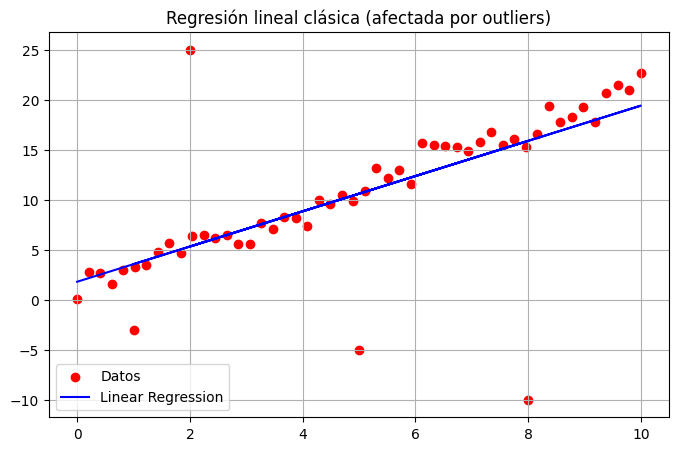

In [15]:
model_lr = LinearRegression()
model_lr.fit(x_out.reshape(-1, 1), y_out)
y_pred_lr = model_lr.predict(x_out.reshape(-1, 1))

plt.figure(figsize=(8, 5))
plt.scatter(x_out, y_out, color='red', label='Datos')
plt.plot(x_out, y_pred_lr, label='Linear Regression', color='blue')
plt.title("Regresión lineal clásica (afectada por outliers)")
plt.legend()
plt.grid(True)
plt.show()


## Regresión de Huber

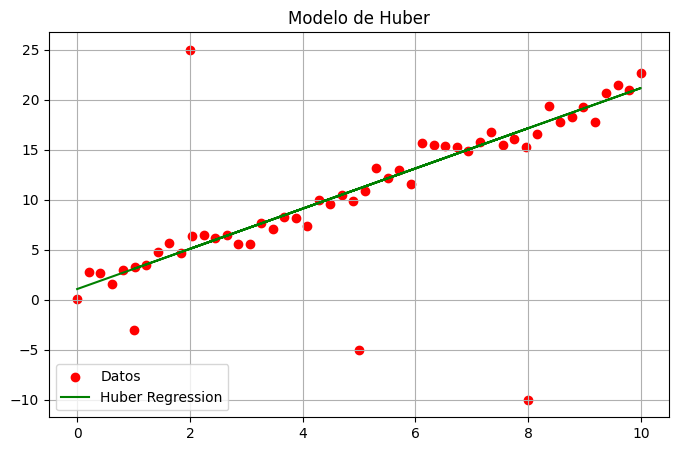

In [16]:
model_huber = HuberRegressor()
model_huber.fit(x_out.reshape(-1, 1), y_out)
y_pred_huber = model_huber.predict(x_out.reshape(-1, 1))

plt.figure(figsize=(8, 5))
plt.scatter(x_out, y_out, color='red', label='Datos')
plt.plot(x_out, y_pred_huber, label='Huber Regression', color='green')
plt.title("Modelo de Huber")
plt.legend()
plt.grid(True)
plt.show()


## RANSAC

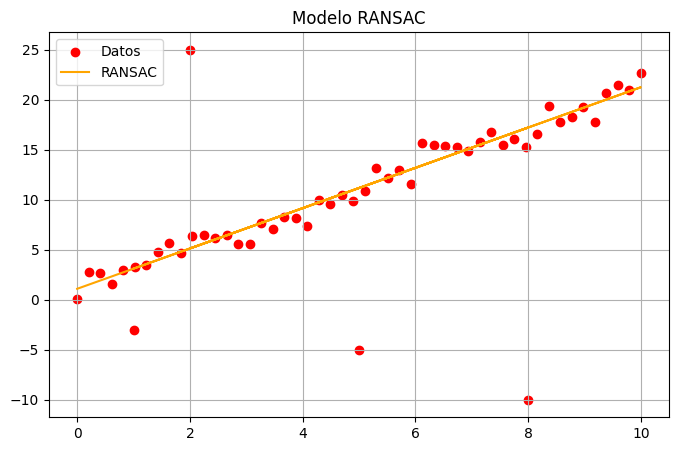

In [17]:
model_ransac = RANSACRegressor()
model_ransac.fit(x_out.reshape(-1, 1), y_out)
y_pred_ransac = model_ransac.predict(x_out.reshape(-1, 1))

plt.figure(figsize=(8, 5))
plt.scatter(x_out, y_out, color='red', label='Datos')
plt.plot(x_out, y_pred_ransac, label='RANSAC', color='orange')
plt.title("Modelo RANSAC")
plt.legend()
plt.grid(True)
plt.show()


## Theil–Sen

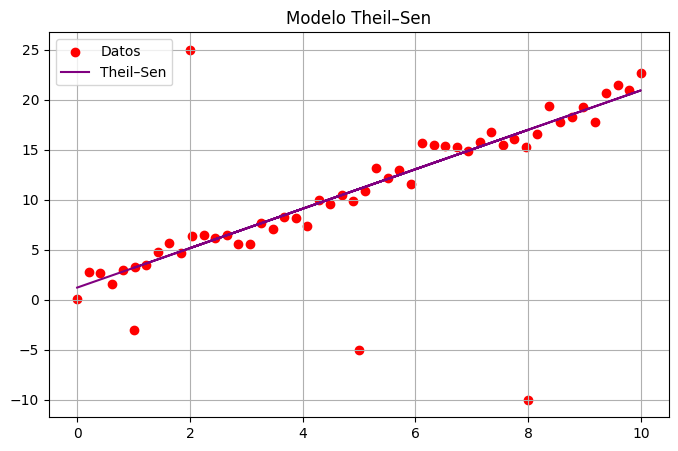

In [18]:
model_theilsen = TheilSenRegressor()
model_theilsen.fit(x_out.reshape(-1, 1), y_out)
y_pred_theilsen = model_theilsen.predict(x_out.reshape(-1, 1))

plt.figure(figsize=(8, 5))
plt.scatter(x_out, y_out, color='red', label='Datos')
plt.plot(x_out, y_pred_theilsen, label='Theil–Sen', color='purple')
plt.title("Modelo Theil–Sen")
plt.legend()
plt.grid(True)
plt.show()


## Comparación de errores (MSE)

In [19]:
mse_lr = mean_squared_error(y_out, y_pred_lr)
mse_huber = mean_squared_error(y_out, y_pred_huber)
mse_ransac = mean_squared_error(y_out, y_pred_ransac)
mse_theilsen = mean_squared_error(y_out, y_pred_theilsen)

print(f"Linear Regression MSE: {mse_lr:.2f}")
print(f"Huber Regression MSE: {mse_huber:.2f}")
print(f"RANSAC MSE: {mse_ransac:.2f}")
print(f"Theil–Sen MSE: {mse_theilsen:.2f}")


Linear Regression MSE: 26.63
Huber Regression MSE: 27.41
RANSAC MSE: 27.49
Theil–Sen MSE: 27.22
